In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_s3.py
%run run connect

2025-06-05 14:04:34,557::INFO::settings.py::Setting loglevel to INFO
2025-06-05 14:04:34,559::INFO::settings.py::Setting stores to {}
2025-06-05 14:04:34,560::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-06-05 14:04:34,561::INFO::settings.py::Setting database.misc.create_tables to True
2025-06-05 14:04:34,562::INFO::settings.py::Setting enable_python_native_blobs to True
2025-06-05 14:04:34,563::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2025-06-05 14:04:34,565::INFO::settings.py::Setting database.user to thomas
2025-06-05 14:04:34,565::INFO::settings.py::Setting database.password to thomas
2025-06-05 14:04:34,616::INFO::connection.py::Connected thomas@128.178.51.167:3309
2025-06-05 14:04:34,633::INFO::table.py::could not log event in table ~log


Connecting thomas@128.178.51.167:3309


2025-06-05 14:04:35,316::INFO::table.py::could not log event in table ~log
2025-06-05 14:04:35,316::INFO::table.py::could not log event in table ~log
2025-06-05 14:04:35,330::INFO::table.py::could not log event in table ~log
2025-06-05 14:04:35,330::INFO::table.py::could not log event in table ~log
2025-06-05 14:04:35,355::INFO::table.py::could not log event in table ~log
2025-06-05 14:04:35,355::INFO::table.py::could not log event in table ~log
2025-06-05 14:04:35,385::INFO::table.py::could not log event in table ~log
2025-06-05 14:04:35,385::INFO::table.py::could not log event in table ~log


In [27]:
from vr4mice.schema.vr4mice import SignalsPhotodiode
from vr4mice.schema.latency_tests import AllLatencies, SignalsPhotodiodeAligned
from vr4mice.analysis.latency_testing import get_signals, find_rising_edges, get_latency
import numpy as np 
import pandas as  pd
import matplotlib.pyplot as plt
import seaborn as sns
from vr4mice.analysis.analysis import style
from matplotlib.colors import ListedColormap 

style()

In [28]:
save_fig_path = "notebooks/Paper_figures/Figure_output/latency/"

In [ ]:
# fetch latency data and transform into dataframe
mathis = (SignalsPhotodiode() & 'dataset LIKE "%Latencytest1%"').fetch("dataset",as_dict=True)
#tolias = (SignalsPhotodiode() & 'dataset LIKE "%Latencytest2%"').fetch("dataset",as_dict=True)
#niel = (SignalsPhotodiode() & 'dataset LIKE "%Latencytest3%"').fetch("dataset",as_dict=True)

df = AllLatencies().fetch(as_dict=True)
df = [pd.DataFrame(d) for d in df]
latencies = pd.concat(df)

In [30]:
mean_latencies =  latencies.groupby(["dataset"], as_index=False).mean()

In [31]:
mean_latencies [["dataset", "time_diff"]]

,dataset,time_diff
0,Latencytest1_2024-10-31_1,0.057624
1,Latencytest1_2024-10-31_2,0.052294
2,Latencytest1_2024-10-31_3,0.055488
3,Latencytest1_2024-10-31_4,0.057332
4,Latencytest1_2024-10-31_5,0.057414
5,Latencytest1_2024-10-31_6,0.056474


0.05597584937966046
0.00915024485453672


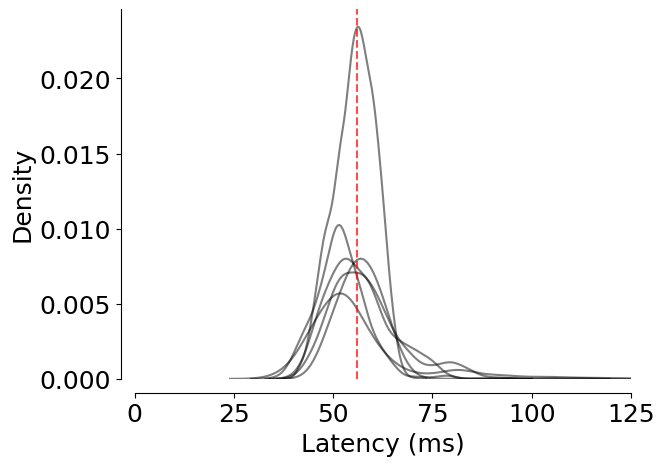

In [34]:
g = sns.kdeplot(data=latencies, x= latencies.time_diff*1000, hue="dataset", palette=ListedColormap(['black']).colors, alpha=0.5, legend=False)
plt.xlim(0,125)
plt.xlabel("Latency (ms)")
plt.axvline(np.mean(latencies.time_diff*1000), c="red", linestyle="dashed", alpha = 0.7)
print(np.mean(latencies.time_diff))
print(np.std(latencies.time_diff))
sns.despine(offset=10)
plt.savefig(save_fig_path + "roundtrip_latency.svg")

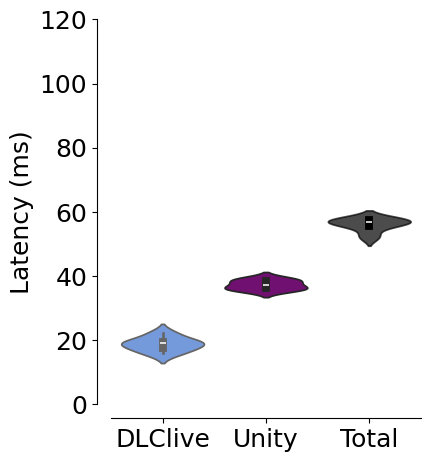

In [35]:
plt.figure(figsize=(4,5))

sns.violinplot(x=np.repeat("DLClive", len(mean_latencies ["time_diff"])), y=abs(mean_latencies ["frame_to_socket"])*1000, color="cornflowerblue")
sns.violinplot(x=np.repeat("Unity", len(mean_latencies ["time_diff"])), y=(abs(mean_latencies ["time_diff"])*1000) - (abs(mean_latencies ["frame_to_socket"])*1000), color="purple")
sns.violinplot(x=np.repeat("Total", len(mean_latencies ["time_diff"])), y=abs(mean_latencies ["time_diff"])*1000, color="black", alpha=0.7)

plt.ylabel("Latency (ms)")
plt.ylim(0,120)
sns.despine(offset=10)
plt.savefig(save_fig_path + "latencies.svg")

In [38]:
# print DLC processing steps latency
print(np.mean(abs(mean_latencies ["frame_to_socket"])*1000))
print(np.std(abs(mean_latencies ["frame_to_socket"])*1000))

18.818355561332528
1.9470439721358412


In [36]:
# Unity render latency
print(np.mean((mean_latencies ["time_diff"]*1000) - (mean_latencies ["frame_to_socket"])*1000))
print(np.std((mean_latencies ["time_diff"]*1000) - (mean_latencies ["frame_to_socket"])*1000))

37.285863881775576
1.3685798421079727


In [37]:
# print total latency
print(np.mean((mean_latencies ["time_diff"])*1000))
print(np.std((mean_latencies ["time_diff"])*1000))

56.1042194431081
1.8515047567944316


In [39]:
df = pd.DataFrame((SignalsPhotodiodeAligned() & 'dataset =  "Latencytest1_2024-10-31_2"').fetch(as_dict=True)[0])

start_time 10.146146774291992


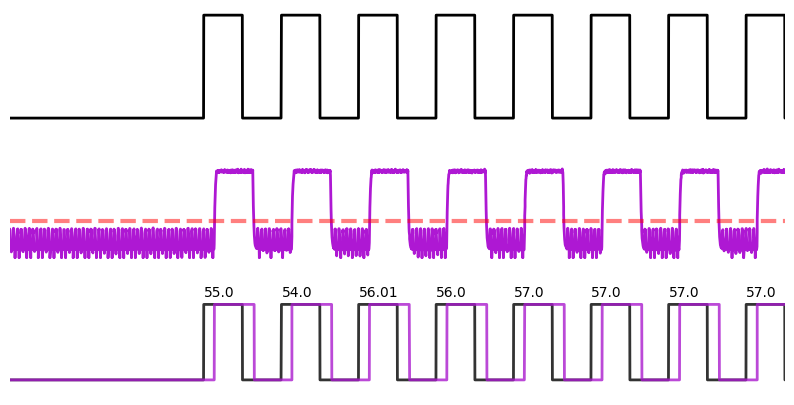

In [47]:
rising_edges_signal = find_rising_edges(df.time_stamp, df.signal_read)
rising_edges_photodiode = find_rising_edges(df.time_stamp, df.photodiode_read)
latencies = get_latency(rising_edges_signal, rising_edges_photodiode)

start_time = df.time_stamp[np.where(df.signal_read == 1)[0][0]]
print("start_time", start_time)

fig, ax = plt.subplots(3,1,figsize=(10,5))
ax[0].plot(df.time_stamp, df.signal_read,c="black",linewidth=2)


ax[1].plot(df.time_stamp, df.photodiode_raw_scaled, c="#AE18D3",linewidth=2)

ax[2].plot(df.time_stamp,  df.signal_read, c="black",linewidth=2,alpha=0.8)
ax[2].plot(df.time_stamp,  df.photodiode_read, c="#AA1BCE",linewidth=2,alpha=0.8)

for ft, td in zip(latencies.frame_time, latencies.time_diff):
    ax[2].annotate(round(td*1000, 2), (ft, 1.1))

ax[1].set_ylim(-0.2,1.3)

ax[1].axhline(0.3,c="red",linestyle="dashed",alpha=0.5, linewidth=3)
ax[2].set_ylim(-0.2,1.3)


sns.despine(offset=10)

for a in ax:
    a.axis('off')
    a.set_xlim(start_time-1,start_time+3)

plt.savefig(save_fig_path + "signal.svg")

In [45]:
df.keys()

Index(['dataset', 'time_stamp', 'send_time', 'frame_to_socket_time',
       'signal_read', 'photodiode_read', 'photodiode_raw_scaled',
       'filtered_photodiode_scaled', 'threshold'],
      dtype='object')